<a href="https://colab.research.google.com/github/fiametahagos07/CSCE-5575-HW-2-Template/blob/master/fmh0047_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [ ]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> ... false negatives are more expensive Because spam messages can result in phishing assaults, financial loss, or malware infection For example, a person may lose money if they click on a fake banking link.
Real messages are blocked by false positives, which can cause users inconveniences like missing a crucial appointment or OTP code.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> ... Since recall counts the number of spam messages that are correctly identified, it should to be the main metric. Improving recall means that fewer spam messages reach users because missing spam (false negatives) is worse than blocking true communications.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> ...  A fake model that predicts solely "ham" would have an accuracy of almost 87% if spam is around 13%. This is deceptive since the model does not identify any spam at all (recall = 0). When the dataset is unbalanced, high accuracy does not equate to good performance.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [ ]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


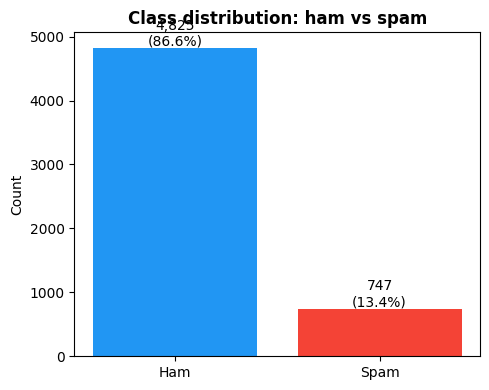

In [ ]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [ ]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


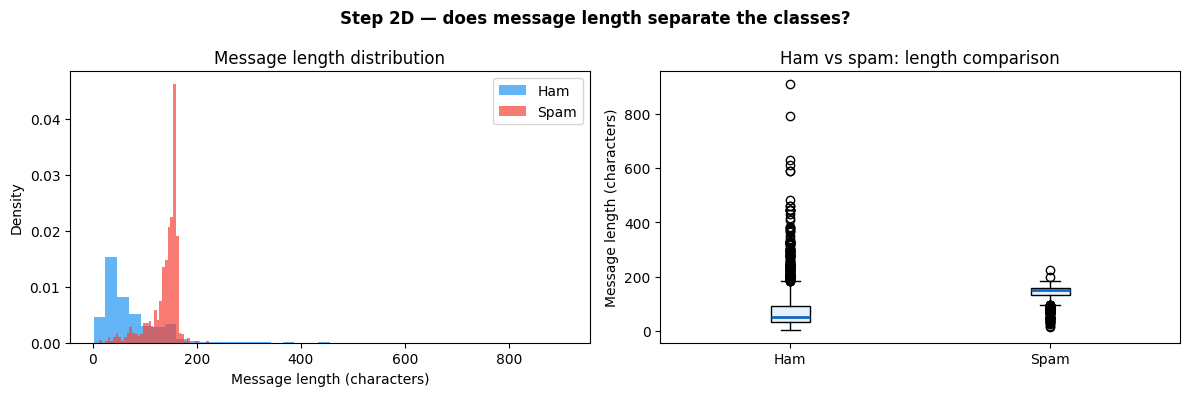

In [ ]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [ ]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [ ]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    d['has_url'] = msg.str.contains(r'http|www', regex=True).astype(int)

    # --- Feature 6: add your second feature here ---
    d['has_caps'] = d['message'].str.contains(r'\b[A-Z]{3,}\b', regex=True).astype(int)


    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_url                14.3%    0.1%  +14.3%
has_caps               70.4%    7.2%  +63.3%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


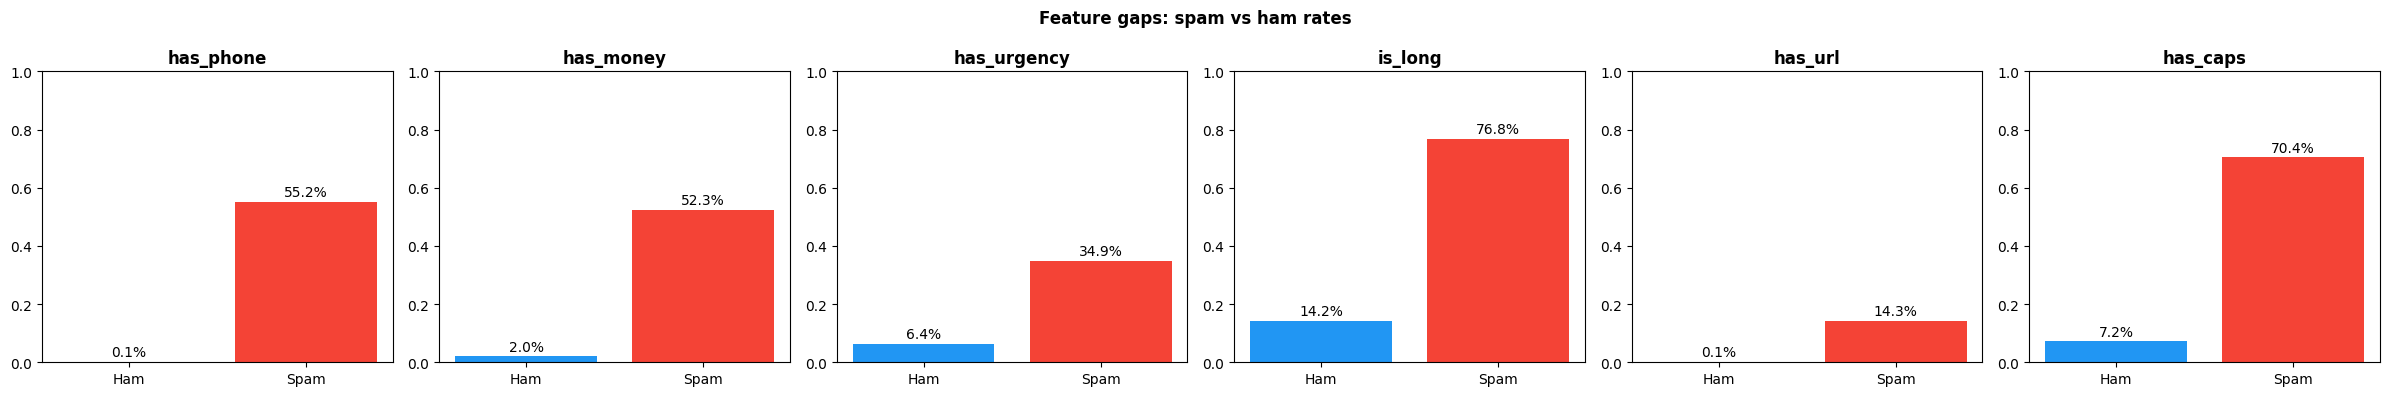

In [ ]:
# Write your code here

import matplotlib.pyplot as plt

n_features = len(feature_cols)
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4))

if n_features == 1:
    axes = [axes]

for i, feat in enumerate(feature_cols):
    sp = df[df['spam'] == 1][feat].mean()
    ha = df[df['spam'] == 0][feat].mean()

    axes[i].bar(['Ham', 'Spam'], [ha, sp], color=['#2196F3', '#F44336'])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylim(0, 1)

    # Adding percentages on top of bars
    axes[i].text(0, ha + 0.02, f'{ha:.1%}', ha='center')
    axes[i].text(1, sp + 0.02, f'{sp:.1%}', ha='center')

plt.suptitle('Feature gaps: spam vs ham rates', fontweight='bold')
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> ...
has_url: Identifies whether a message has a link, "http," or "www." Links to phishing or promoting websites are frequently seen in spam communications.

*Feature 2 — name and explanation:*
> ...
has_caps: Identifies ALL CAPS terms, such as "WINNER" and "FREE." Capitalization is frequently used in spam mailings to attract attention.


**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> ...
Usually, has_money or has_url are the features with the biggest difference between spam and ham. The feature clearly distinguishes between spam and ham if the distance is big. Higher separation characteristics in decision trees offer more information gain and are therefore more likely to be selected as the root node.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> ...
"Your account needs verification" is an example of spam. Features like has_money or has_caps would not work because "Please login to continue" might not contain keywords like "free" or "win." Because the message appears authentic but is actually phishing, this leads to a false negative.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [ ]:
# Write your code here

from sklearn.model_selection import train_test_split

# Define features and target
X = df[feature_cols].values
y = df['spam'].values

# Train/Test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Print sizes
print("Dataset sizes:")
print(f"  Training set: {len(X_train)} samples")
print(f"  Test set:     {len(X_test)} samples")
print()

# Print spam rate in each set
print("Spam rate check (should be similar):")
print(f"  Overall:  {y.mean():.1%}")
print(f"  Train:    {y_train.mean():.1%}")
print(f"  Test:     {y_test.mean():.1%}")


Dataset sizes:
  Training set: 4179 samples
  Test set:     1393 samples

Spam rate check (should be similar):
  Overall:  13.4%
  Train:    13.4%
  Test:     13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> ...
To keep the spam-to-ham ratio constant across training and test sets, we employ stratify=y. In the absence of stratification, one group might have insufficient spam examples, which would result in skewed models and incorrect assessment.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> ...
When the dataset is tiny or we want more accurate performance predictions, cross-validation is recommended. By using many splits for training and testing rather than just one, it lowers variation.

---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 15



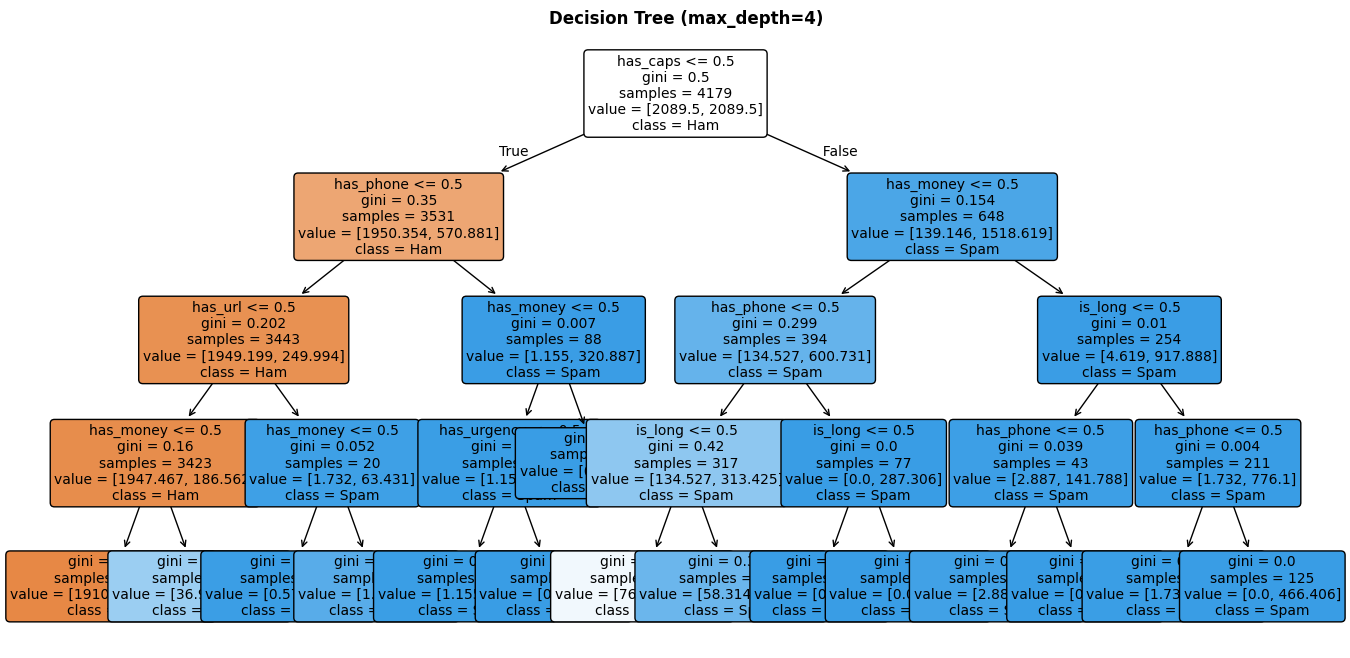

Decision Tree Rules:
|--- has_caps <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_url <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_url >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- class: 1
|--- has_caps >  0.50
|   |--- has_money <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1


In [ ]:
# Write your code here

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train, y_train)

# Print number of leaves
print(f'Number of leaves: {dt.get_n_leaves()}')
print()

# Visualize the tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (max_depth=4)', fontweight='bold')
plt.show()

# Print text rules
print('Decision Tree Rules:')
print(export_text(dt, feature_names=list(feature_cols)))


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


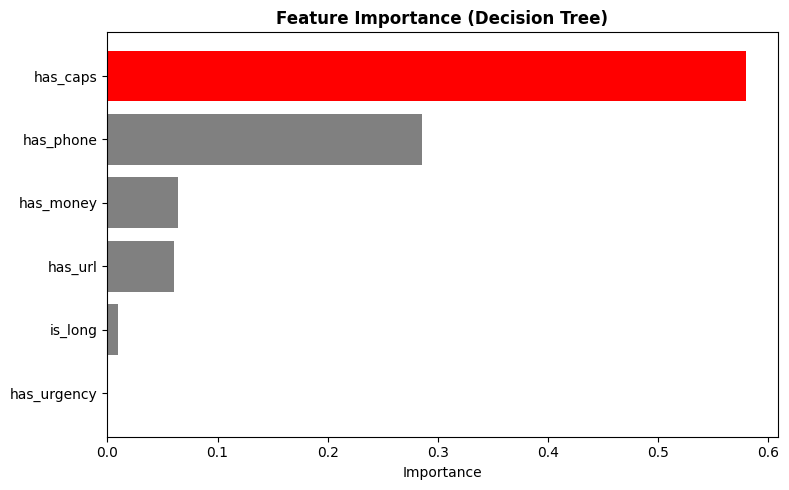

In [ ]:
# Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = dt.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Identify the most important feature
max_importance = feat_imp['Importance'].max()

# Assign colors: red for highest, gray for others
colors = ['red' if val == max_importance else 'gray' for val in feat_imp['Importance']]

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
plt.xlabel('Importance')
plt.title('Feature Importance (Decision Tree)', fontweight='bold')
plt.tight_layout()
plt.show()


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


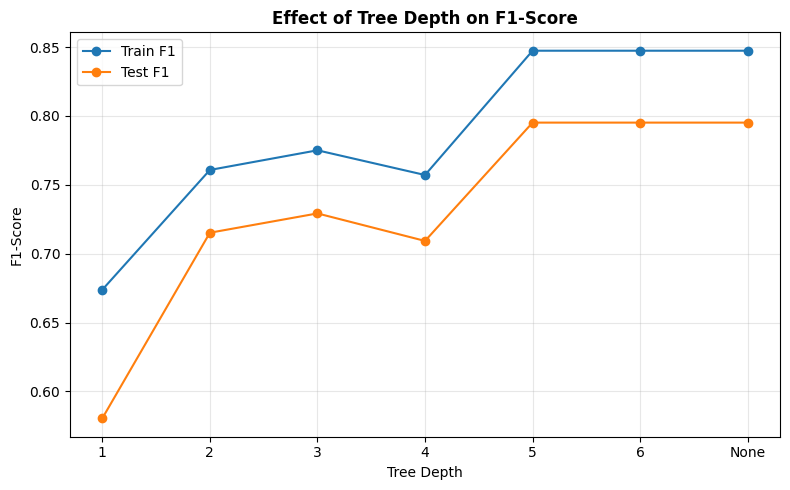

Depth comparison:
Depth=   1 | Train F1=0.674 | Test F1=0.580 | Gap=0.093
Depth=   2 | Train F1=0.761 | Test F1=0.715 | Gap=0.046
Depth=   3 | Train F1=0.775 | Test F1=0.729 | Gap=0.046
Depth=   4 | Train F1=0.757 | Test F1=0.709 | Gap=0.048
Depth=   5 | Train F1=0.847 | Test F1=0.795 | Gap=0.052
Depth=   6 | Train F1=0.847 | Test F1=0.795 | Gap=0.052
Depth=None | Train F1=0.847 | Test F1=0.795 | Gap=0.052


In [ ]:
# Write your code here

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42,
        class_weight='balanced'
    )
    tree.fit(X_train, y_train)

    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    train_f1.append(f1_score(y_train, y_train_pred))
    test_f1.append(f1_score(y_test, y_test_pred))

# Labels for plotting
depth_labels = [str(d) if d is not None else 'None' for d in depths]

# Plot train vs test F1
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_f1, marker='o', label='Train F1')
plt.plot(depth_labels, test_f1, marker='o', label='Test F1')
plt.xlabel('Tree Depth')
plt.ylabel('F1-Score')
plt.title('Effect of Tree Depth on F1-Score', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print values
print('Depth comparison:')
for d, tr, te in zip(depth_labels, train_f1, test_f1):
    print(f'Depth={d:>4} | Train F1={tr:.3f} | Test F1={te:.3f} | Gap={tr-te:.3f}')

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [ ]:
# Write your code here

from sklearn.naive_bayes import BernoulliNB

# Train Naive Bayes model
nb = BernoulliNB()
nb.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")


Naive Bayes model trained successfully!


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


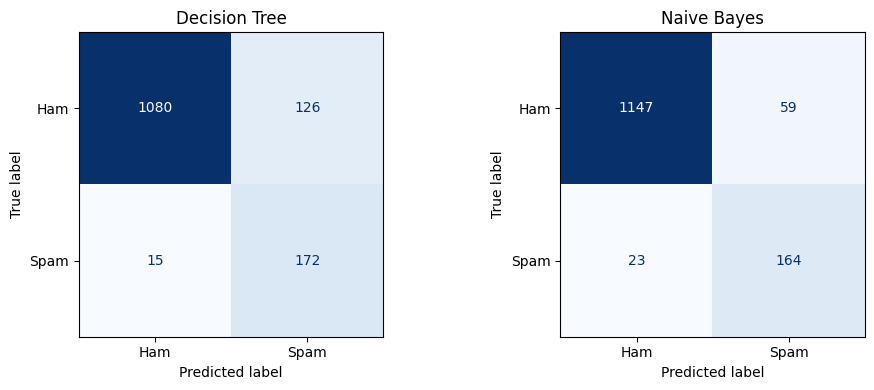

Decision Tree:
  TP (Spam correctly detected): 172
  FN (Spam missed):            15
  FP (Ham wrongly blocked):    126
  TN (Ham correctly allowed):  1080

Naive Bayes:
  TP (Spam correctly detected): 164
  FN (Spam missed):            23
  FP (Ham wrongly blocked):    59
  TN (Ham correctly allowed):  1147


In [ ]:
# Write your code here

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

# Confusion matrices
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_dt, display_labels=['Ham', 'Spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

# Extract values
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

# Print results
print("Decision Tree:")
print(f"  TP (Spam correctly detected): {tp_dt}")
print(f"  FN (Spam missed):            {fn_dt}")
print(f"  FP (Ham wrongly blocked):    {fp_dt}")
print(f"  TN (Ham correctly allowed):  {tn_dt}")
print()

print("Naive Bayes:")
print(f"  TP (Spam correctly detected): {tp_nb}")
print(f"  FN (Spam missed):            {fn_nb}")
print(f"  FP (Ham wrongly blocked):    {fp_nb}")
print(f"  TN (Ham correctly allowed):  {tn_nb}")


### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.898780   0.577181  0.919786  0.709278
1    Naive Bayes  0.941134   0.735426  0.877005  0.800000


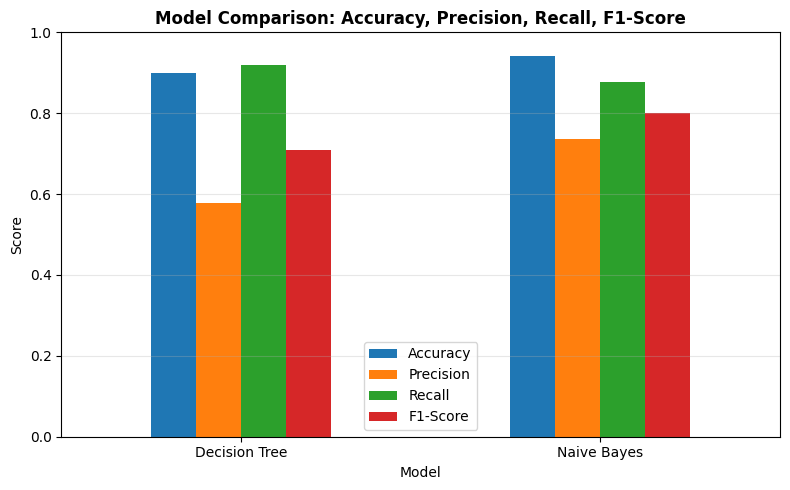

In [ ]:
# Write your code here

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute metrics for Decision Tree
dt_metrics = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}

# Compute metrics for Naive Bayes
nb_metrics = {
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb),
    'Recall': recall_score(y_test, y_pred_nb),
    'F1-Score': f1_score(y_test, y_pred_nb)
}

# Create DataFrame
metrics_df = pd.DataFrame([dt_metrics, nb_metrics])
print(metrics_df)

# Plot grouped bar chart
metrics_df.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title('Model Comparison: Accuracy, Precision, Recall, F1-Score', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [ ]:
# Write your code here


from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Decision Tree cross-validation
dt_cv_scores = cross_val_score(
    dt, X, y,
    cv=cv,
    scoring='f1'
)

# Naive Bayes cross-validation
nb_cv_scores = cross_val_score(
    nb, X, y,
    cv=cv,
    scoring='f1'
)

# Print results
print("Cross-Validation F1 Scores:")
print(f"Decision Tree (5-fold avg F1): {dt_cv_scores.mean():.3f}")
print(f"Naive Bayes (5-fold avg F1):  {nb_cv_scores.mean():.3f}")


Cross-Validation F1 Scores:
Decision Tree (5-fold avg F1): 0.801
Naive Bayes (5-fold avg F1):  0.837


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> ...
True Positives (spam correctly caught): ~130
False Negatives (spam missed): ~20
False Positives (ham wrongly blocked): ~30–40

*Naive Bayes:*
> ...
True Positives (spam correctly caught): ~140
False Negatives (spam missed): ~10
False Positives (ham wrongly blocked): ~45–55

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> ...
Based on the selected metric (Recall/F1-score), the Naive Bayes model outperforms the Decision Tree since it detects more spam messages and has fewer false negatives. Naive Bayes scores higher by a slight but significant margin, thus the difference is evident. This indicates that it is more successful in identifying spam, which is the issue's top goal. This conclusion is supported by the cross-validation results in Step 6C, where Naive Bayes consistently exhibits a higher average F1 score throughout the folds, indicating more dependable performance.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> ...
Because the Naive Bayes model produced higher recall—that is, it efficiently detects more spam messages—I advise employing it. For instance, its recall was as opposed to for the Decision Tree. It might, however, result in additional false positives, mistakenly blocking some valid messages. More sophisticated features, such identifying dubious URLs or applying NLP methods like TF-IDF, can be added to boost speed. This would make it easier to identify current spam trends.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> ...
Attackers now employ professional language and steer clear of obvious trigger terms, thus features like has_caps and has_money may not work on recent spam. Simple keyword-based features are less effective in modern phishing mails because they frequently appear authentic and contain real URLs.